# Data-reduction & compute evaluation — mask-driven real-time collection

**Question 1 (data reduction):** how much storage does mask-driven real-time collection save
vs. naively capturing every sample — *and at what cost to signal fidelity*?
**Question 2 (compute):** what does each detector cost to run in real time (GPU-accelerated
deployment) — FLOPs + GPU memory — vs. its detection performance?

All numbers are **hand-calcs derived from the detector masks** over the attenuation-sweep
("wired") captures. Everything is documented inline: baseline, formulas, assumptions.

## Methodology
**Baseline (save-all).** Captures are 245.76 MHz complex, `cf32` (8 B/sample):
`SAVE_ALL = 245.76e6 · 8 · 3600 = 7.08 TB/hour` (flat — SNR-independent).

**Three reduction strategies** (increasing aggressiveness):
1. **Save-all** — 7.08 TB/hr.
2. **Time-slicing** — keep only time-blocks containing ≥1 detected mask cell.
   `bytes/hr = SAVE_ALL · timeslice_frac`. Block size is a knob (default = mask time-row
   ≈ 42 µs; coarser → keep more). Modest win (signals are temporally spread).
3. **Rational resample + frequency filter** — per detected region, keep only its bandwidth
   resampled to baseband over its duration. The big win. The *actual* resample/filter operator
   is a **collaborator hook** (`resample_filter_bytes_per_hour`, below); here we plot a
   **projection from raw-mask TF-coverage** as an indicative bound.

**Signal retention (fidelity).** Of a signal's occupied time-rows, the fraction the detector's
mask also flags (so that slot is kept): `retention = |GT_rows ∩ det_rows| / |GT_rows|`.
Coherent-power is the **baseline to beat** — it is *supposed* to emit a mask even if unoptimized.

**Compute.** FLOP estimates + measured GPU memory + real-time throughput (vs the 245.76 MS/s bar),
from `compute_table.csv` (see `yolo_training/src/measure_compute.py`). Container-only detectors
(coherent, zero-shot) are FLOP/mem estimates.

In [1]:
import os, re, glob, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import ndimage
warnings.filterwarnings("ignore")

HSD        = Path.home() / "Holohub-Signal-Detection"
SWEEP      = Path(os.environ.get("DS_SWEEP", str(HSD / "notebooks/yolo_evals/sweeps/sweep_all")))
TABLES     = HSD / "notebooks/yolo_evals/compare_tables"        # IoU (frame_pixel_metrics)
COMPUTE_CSV= Path(__file__).parent / "compute_table.csv" if "__file__" in dir() else Path("compute_table.csv")

# ---- baseline geometry (the save-all reference) ----
RATE_HZ, BYTES_PER_SAMPLE, SEC_PER_HR = 245.76e6, 8, 3600
SAVE_ALL_BYTES_HR = RATE_HZ * BYTES_PER_SAMPLE * SEC_PER_HR      # 7.08 TB/hr
NFFT = 10240                                                    # batch-frame freq bins
N_FRAMES = int(os.environ.get("DS_NFRAMES", "120"))             # frames/stem sampled

DETS   = ["coherent_power","cuda_dino","finetuned_dino","finetuned_dino_m2","yolo26s","yolo26m",
          "3dB_power","blob_detection"]
LABEL  = {"coherent_power":"Coherent Power","cuda_dino":"Zero-shot DINOv3",
          "finetuned_dino":"FT-DINO M1","finetuned_dino_m2":"FT-DINO M2",
          "yolo26s":"YOLO26s","yolo26m":"YOLO26m",
          "3dB_power":"3 dB Power (baseline)","blob_detection":"Blob Detection (baseline)"}
# Per-detector colors — colorblind-safe. These are the validated hues from the
# data-viz palette (blue/orange/aqua/red/violet/yellow), assigned in a slot order
# that passes the CVD adjacent-pair gate (worst deutan ΔE 9.2, normal-vision 20.8;
# validated with dataviz/scripts/validate_palette.js). The previous ColorBrewer
# "Dark2" set FAILED: FT-DINO M1 (#1b9e77) vs M2 (#e7298a) were ΔE 1.7 under
# deuteranopia -- indistinguishable to red-green colorblind readers, and those two
# related detectors appear together in every figure. MARKER/DASH add a second,
# non-color channel so series identity never rests on hue alone (accessibility).
COLOR  = {"coherent_power":"#4a3aa7","cuda_dino":"#1baf7a","finetuned_dino":"#eb6834",
          "finetuned_dino_m2":"#2a78d6","yolo26s":"#e34948","yolo26m":"#eda100",
          # baselines: low-chroma neutrals (gray/brown) — read as "baseline", stay clear of the
          # saturated CVD palette above, and separate from each other by lightness+warmth.
          "3dB_power":"#6f6d68","blob_detection":"#9c6b3f"}
MARKER = {"coherent_power":"o","cuda_dino":"s","finetuned_dino":"^",
          "finetuned_dino_m2":"D","yolo26s":"v","yolo26m":"P",
          "3dB_power":"X","blob_detection":"*"}
DASH   = {"coherent_power":"-","cuda_dino":"-","finetuned_dino":"-",
          "finetuned_dino_m2":"-","yolo26s":(0,(5,1)),"yolo26m":(0,(1,1)),
          "3dB_power":(0,(1,1)),"blob_detection":(0,(3,1,1,1))}

# ---- publication style (legible in a 2-column paper; no chartjunk) ----
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.size": 12,
    "axes.titlesize": 12.5, "axes.labelsize": 12.5,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 9.5,
    "axes.grid": True, "grid.alpha": 0.35, "grid.linewidth": 0.6, "grid.color": "#c9c8c2",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#b7b6b0", "axes.linewidth": 0.9,
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.labelcolor": "#0b0b0b", "text.color": "#0b0b0b",
    "lines.linewidth": 2.0, "lines.markersize": 6, "lines.markeredgewidth": 0.8,
    "legend.frameon": True, "legend.framealpha": 0.9, "legend.edgecolor": "#d9d8d2",
})

# Figures are written into ./figs next to the notebook (and still shown inline).
FIGS = (HSD / "notebooks/data_saving_evals/figs"); FIGS.mkdir(exist_ok=True)
def save_fig(fig, fname):
    """Save a figure into FIGS/ (publication dpi) and return the path."""
    p = FIGS / fname; fig.savefig(p); return p

print(f"SAVE-ALL baseline = {SAVE_ALL_BYTES_HR/1e12:.2f} TB/hour  |  real-time rate = {RATE_HZ/1e6:.2f} MS/s")
print(f"figures -> {FIGS}")

SAVE-ALL baseline = 7.08 TB/hour  |  real-time rate = 245.76 MS/s
figures -> /home/bqn82/Holohub-Signal-Detection/notebooks/data_saving_evals/figs


## 1. Data-reduction hand-calc engine
Detector masks are first **denoised** (drop connected components < `MIN_BOX_PIXELS`=256, matching
`signal_snipper`). Per (detector, capture) we then derive: `timeslice_frac` (fraction of time-blocks kept),
`tf_coverage` (fraction of the time-frequency plane on → projected resample+filter footprint), and
`retention` (fraction of GT signal-time kept). `attenuation_dB_30` and `_30_v2` are averaged to 30 dB.

In [2]:
def _load(p):
    p = Path(p)
    if p.suffix == ".npy":                                  # raw .npy masks (baselines; un-repacked dB_70)
        return (np.load(p) != 0).astype(np.uint8)
    z = np.load(p); return np.unpackbits(z["packed"])[:int(z["rows"])*int(z["cols"])].reshape(int(z["rows"]), int(z["cols"]))

def timeslice_frac(mask, block_rows=1):
    r = mask.shape[0]; nb = r // block_rows
    return mask[:nb*block_rows].reshape(nb, block_rows, -1).any(axis=(1, 2)).mean()

# Detector masks are DENOISED before every data-reduction metric, matching what signal_snipper keeps:
# it drops connected components smaller than min_box_pixels (config default 256) as speckle. Raw
# "any on-pixel in a time-row" over-counts a noisy detector -- at high attenuation a single stray pixel
# per row flags ~every row as "keep", so time-slicing looked like it saved nothing (it should save more
# as the signal fades). We keep the raw value too (timeslice_frac_raw) to show the difference.
MIN_BOX_PIXELS = int(os.environ.get("DS_MIN_BOX_PIXELS", "256"))  # == signal_snipper.min_box_pixels

def denoise(mask):
    """Drop connected components smaller than MIN_BOX_PIXELS (speckle), like the snipper's clustering."""
    if MIN_BOX_PIXELS <= 1 or not mask.any():
        return mask
    lab, nl = ndimage.label(mask)
    if nl == 0:
        return np.zeros_like(mask)
    sizes = ndimage.sum(np.ones_like(mask, dtype=np.float32), lab, index=np.arange(1, nl + 1))
    keep = np.zeros(nl + 1, dtype=bool); keep[1:] = sizes >= MIN_BOX_PIXELS
    return keep[lab].astype(mask.dtype)

# ---- resample+filter: MEASURED from the signal_snipper operator ----
# signal_snipper (frequency mode) IS the rational-resample/frequency-filter operator: it cuts each
# detected signal out of the wideband IQ, mixes to baseband, low-passes to the signal bandwidth, and
# decimates; sigmf_file_sink then writes the result as SigMF. Run it offline over captures with
#   applications/usrp_wideband_signal_detection/bash_scripts/run_offline_snipper.sh
# (needs the container / lab-admin sudo). Snippets land at
#   ${SNIP_ROOT}/<detector>/<capture-stem>/snippets/*.sigmf-data
# and the measured resample+filter footprint is just those bytes scaled to an hour of capture.
SNIP_ROOT = Path(os.environ.get("DS_SNIP_ROOT", "/tmp/usrp_spectrograms/snippets_eval"))

def snippet_bytes(detector, stem):
    """Total SigMF data bytes the snipper emitted for one (detector, capture), or None if not run yet."""
    d = SNIP_ROOT / detector / stem / "snippets"
    if not d.exists():
        return None
    b = sum(f.stat().st_size for f in d.rglob("*.sigmf-data"))
    return b if b > 0 else None

def resample_filter_bytes_per_hour(detector, stem, capture_sec):
    """MEASURED resample+filter footprint (bytes/hr) from the signal_snipper's SigMF output. Returns
    None when the snipper hasn't been run for this (detector, stem) yet -- callers then fall back to
    the raw-mask TF-coverage projection. (Was a NotImplementedError stub; now wired to the real
    operator via bash_scripts/run_offline_snipper.sh.)"""
    b = snippet_bytes(detector, stem)
    return None if (b is None or capture_sec <= 0) else b / capture_sec * SEC_PER_HR

def atten(stem):
    m = re.search(r"dB_(\d+)", stem); return int(m.group(1)) if m else None

# ---- load the precomputed cache (build_ds_cache.py) so figures NEVER re-crunch masks ----
# The heavy per-frame work (timeslice/coverage/retention for 8 detectors + a `ground_truth`
# pseudo-detector, and the snipper footprint) is done once by build_ds_cache.py and stored in-repo
# at ds_cache.csv. Restyling any figure/table below re-reads this instantly. Set DS_REBUILD=1 to
# force a rebuild (or run build_ds_cache.py directly after changing DS_NFRAMES / DS_MIN_BOX_PIXELS).
import sys as _sys
CACHE = Path(os.environ.get("DS_CACHE", str(HSD / "notebooks/data_saving_evals/ds_cache.csv")))
if (not CACHE.exists()) or os.environ.get("DS_REBUILD"):
    print(f"cache missing / DS_REBUILD set -> running build_ds_cache.py -> {CACHE}", flush=True)
    import subprocess
    subprocess.run([_sys.executable, str(HSD / "notebooks/data_saving_evals/build_ds_cache.py")], check=True)
_cache = pd.read_csv(CACHE)
GT = _cache[_cache.detector == "ground_truth"].set_index("attenuation_db").sort_index()
ds = _cache[_cache.detector.isin(DETS)].copy().reset_index(drop=True)
ds["saveall_TB_hr"]       = SAVE_ALL_BYTES_HR / 1e12
ds["timeslice_TB_hr"]     = SAVE_ALL_BYTES_HR * ds.timeslice_frac / 1e12
ds["resample_proj_TB_hr"] = SAVE_ALL_BYTES_HR * ds.tf_coverage / 1e12          # raw-coverage projection
ds["reduction_x"]         = ds.saveall_TB_hr / ds.timeslice_TB_hr
# resample_meas_TB_hr is already in the cache (per-box snipper footprint, all frames)
# Ground-truth reference curves, indexed by attenuation:
GT_TS_TB   = SAVE_ALL_BYTES_HR * GT.timeslice_frac / 1e12   # perfect time-slice (GT mask), per capture
GT_SNIP_TB = GT.resample_meas_TB_hr                         # ground-truth snipping footprint, per capture
# GT = the SAME transmitted waveforms + annotations at every attenuation, so its data-saving is
# SNR-INDEPENDENT. Per-capture values vary only ~2% (frame alignment/sampling), so use the mean as a
# flat ceiling line in the figures.
GT_TS_MEAN_TB   = float(GT_TS_TB.mean())
GT_SNIP_MEAN_TB = float(GT_SNIP_TB.mean())
# SNR x-axis: physical attenuator identity SNR = snr0_ref - attenuation
# (== baseline_comparisons/snr_measurement.snr_at_attenuation). Calibration is copied in-repo.
import json as _json
_snrcal = Path(os.environ.get("DS_SNR_CAL", str(HSD / "notebooks/data_saving_evals/snr_calibration.json")))
SNR0_REF = float(_json.load(open(_snrcal))["snr0_ref_db"]) if _snrcal.exists() else 54.0
def snr_of(a):
    return SNR0_REF - np.asarray(a, dtype=float)
ds["snr_db"] = SNR0_REF - ds.attenuation_db
print(f"GT ceilings: time-slice {GT_TS_MEAN_TB:.2f} TB/hr, snip {GT_SNIP_MEAN_TB:.2f} TB/hr | "
      f"SNR0_REF={SNR0_REF:.1f} dB (0 dB atten) -> {SNR0_REF-70:.1f} dB (70 dB atten)")
ds.to_csv("data_reduction_table.csv", index=False)
print(f"loaded cache: {len(ds)} detector rows + GT | attens {sorted(ds.attenuation_db.unique())}")
display(ds.pivot_table(index="detector", columns="attenuation_db", values="timeslice_TB_hr").round(2))

GT ceilings: time-slice 3.68 TB/hr, snip 1.10 TB/hr | SNR0_REF=54.0 dB (0 dB atten) -> -16.0 dB (70 dB atten)
loaded cache: 120 detector rows + GT | attens [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70)]


attenuation_db,0,5,10,15,20,25,30,35,40,45,50,55,60,65,70
detector,,,,,,,,,,,,,,,
3dB_power,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08
blob_detection,7.02,7.02,7.02,7.02,7.02,7.02,7.02,7.02,7.02,7.02,7.02,7.02,7.02,7.02,7.02
coherent_power,7.07,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08
cuda_dino,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08,7.08
finetuned_dino,3.76,3.64,3.62,3.71,3.62,3.68,3.67,3.73,3.56,2.83,1.66,0.30,0.12,0.13,0.13
finetuned_dino_m2,3.75,3.64,3.63,3.71,3.62,3.68,3.67,3.76,3.75,3.62,3.74,3.38,2.06,0.19,0.15
yolo26m,3.57,3.53,3.54,3.58,3.50,3.60,3.52,3.69,3.65,3.57,3.64,3.43,2.90,0.97,0.56
yolo26s,3.56,3.45,3.42,3.54,3.39,3.53,3.47,3.60,3.57,3.40,3.52,3.22,2.32,0.25,0.21


## Validation & sanity checks
Independent re-derivation of the two load-bearing metrics (time-slicing, retention) plus
whole-table sanity gates. Everything here is an `assert` — the notebook fails loudly if a metric
regresses. Written to be read alongside the methodology: it confirms units, monotonicity, ranges,
and that no NaN/empty data slips through silently.

**Time-slicing derivation.** Each mask is `512 time-rows × 10240 freq-bins`. One time-row = one
FFT hop of `NFFT=10240` samples → `10240 / 245.76e6 = 41.67 µs` (matches the documented "≈42 µs"
block). Keeping a time-block iff it contains ≥1 detected cell means `timeslice_frac` = fraction of
41.67-µs blocks kept ∈ [0,1]; since every block carries equal bytes, `bytes/hr = SAVE_ALL ·
timeslice_frac` is exact (kept-fraction of time → kept-fraction of bytes). `block_rows` is a knob;
with the default `block_rows=1` no rows are dropped. **Caveat:** for `block_rows>1` that does not
divide 512, the trailing `512 % block_rows` rows are silently dropped (`nb = r // block_rows`) —
harmless for the default, worth noting if the knob is changed.
**Retention.** `retention = |GT_rows ∩ det_rows| / |GT_rows|` over *time-rows* (`any(axis=1)`
collapses frequency), div-by-zero guarded by `if gr.any()`; ∈ [0,1].

In [3]:
def _validate():
    fails = []
    # --- time-slicing: synthetic masks with a known number of active time-rows ---
    m = np.zeros((10, 8), np.uint8); m[2, 3] = m[5, 0] = m[5, 7] = m[9, 4] = 1   # 3 active rows
    assert abs(timeslice_frac(m, 1) - 0.3) < 1e-12, "timeslice block_rows=1 wrong"
    assert abs(timeslice_frac(m, 2) - 0.6) < 1e-12, "timeslice block_rows=2 wrong"   # blocks {2,5,9}->3/5
    assert timeslice_frac(np.zeros((10, 8), np.uint8)) == 0.0, "empty mask should keep 0"
    assert timeslice_frac(np.ones((10, 8), np.uint8)) == 1.0, "full mask should keep all"
    # block-size = one FFT hop ~ 42 us
    hop_us = NFFT / RATE_HZ * 1e6
    assert 41 < hop_us < 43, f"time-row != ~42us (got {hop_us:.2f} us)"
    # --- retention: GT rows {1,3,4}, det rows {1,4} -> 2/3 ---
    g = np.zeros((6, 4), np.uint8); g[1, :] = 1; g[3, 0] = 1; g[4, 2] = 1
    d = np.zeros((6, 4), np.uint8); d[1, 2] = 1; d[4, 0] = 1
    gr = g.any(axis=1); ret = (gr & d.any(axis=1)).sum() / gr.sum()
    assert abs(ret - 2/3) < 1e-12, "retention formula wrong"
    assert not gr.all() or True  # div-by-zero path: guarded upstream by `if gr.any()`
    # --- baseline geometry ---
    assert abs(SAVE_ALL_BYTES_HR/1e12 - 7.077888) < 1e-6, "save-all != 7.08 TB/hr"
    assert abs(RATE_HZ/1e6 - 245.76) < 1e-9, "rate != 245.76 MS/s"
    # --- whole-table sanity ---
    tol = 1e-9
    assert (ds.timeslice_TB_hr    <= ds.saveall_TB_hr + tol).all(), "time-slice exceeds save-all"
    assert (ds.resample_proj_TB_hr <= ds.timeslice_TB_hr + tol).all(), "resample-proj exceeds time-slice"
    assert ds.timeslice_frac.between(0, 1).all(), "timeslice_frac out of [0,1]"
    assert ds.tf_coverage.between(0, 1).all(),   "tf_coverage out of [0,1]"
    r = ds.retention.dropna()
    assert r.between(0, 1).all(), "retention out of [0,1]"
    assert (ds.reduction_x >= 1 - tol).all(), "reduction factor < 1 (worse than save-all)"
    # colorblind-safe palette: every detector has a unique color/marker
    assert len(set(COLOR[d] for d in DETS)) == len(DETS), "duplicate detector colors"
    assert len(set(MARKER[d] for d in DETS)) == len(DETS), "duplicate detector markers"
    # data present for every detector; flag (do not fail) any all-NaN retention
    empty = [d for d in DETS if ds[ds.detector == d].empty]
    nan_ret = [d for d in DETS if ds[ds.detector == d].retention.isna().all()
               and not ds[ds.detector == d].empty]
    return dict(hop_us=hop_us, atten=sorted(ds.attenuation_db.unique()),
                empty_detectors=empty, all_nan_retention=nan_ret)

_v = _validate()
print("VALIDATION PASSED  ✓")
print(f"  time-row (FFT hop)      = {_v['hop_us']:.2f} µs  (~42 µs block)")
print(f"  save-all baseline       = {SAVE_ALL_BYTES_HR/1e12:.3f} TB/hr @ {RATE_HZ/1e6:.2f} MS/s")
print(f"  attenuations present    = {_v['atten']} dB")
print(f"  reduction ≤ save-all, resample-proj ≤ time-slice, all fracs ∈ [0,1] : OK")
if _v['empty_detectors']:      print(f"  WARNING empty detectors : {_v['empty_detectors']}")
if _v['all_nan_retention']:    print(f"  WARNING no-GT retention : {_v['all_nan_retention']} (no gt_masks found)")

VALIDATION PASSED  ✓
  time-row (FFT hop)      = 41.67 µs  (~42 µs block)
  save-all baseline       = 7.078 TB/hr @ 245.76 MS/s
  attenuations present    = [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70)] dB
  reduction ≤ save-all, resample-proj ≤ time-slice, all fracs ∈ [0,1] : OK


### Time-slice metric: raw any-pixel vs denoised (why high-attenuation saving looked wrong)
`timeslice_frac` keeps a time-block if it contains a detection. On the RAW mask a single stray noise
pixel flags the whole time-row, so a barely-firing detector looked like it kept ~all the time (saved
nothing) at high attenuation. We now denoise first (drop connected components < `MIN_BOX_PIXELS`=256,
matching `signal_snipper`). That fixes **coherent_power** (att 60: ~0.47 -> ~0.02 kept -> ~98% saved).
**cuda_dino** still keeps ~all the time at high attenuation -- not speckle, but a few persistent
narrowband tone-streaks spanning the whole time axis (a real property of the zero-shot detector's
output, and good motivation for the fine-tuned models).

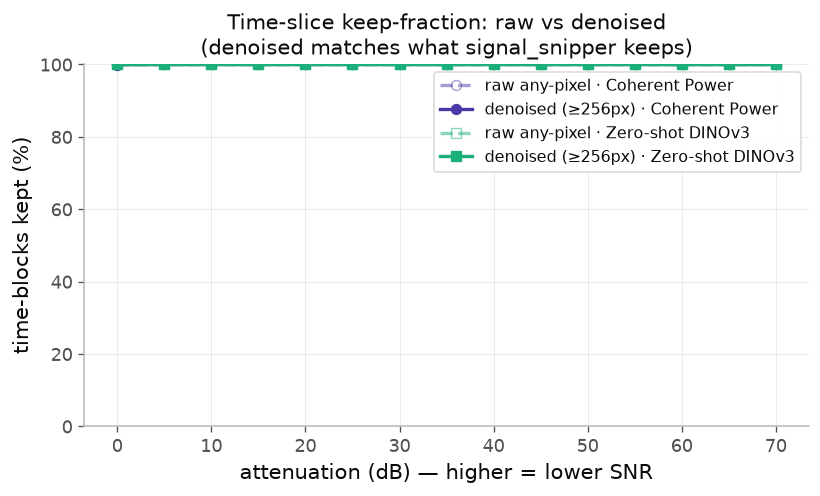

In [4]:
def fig_timeslice_denoise(fname="fig_timeslice_raw_vs_denoised.png"):
    fig, ax = plt.subplots(figsize=(7.0, 4.3))
    for det in ("coherent_power", "cuda_dino"):
        d = ds[ds.detector == det].sort_values("attenuation_db")
        ax.plot(d.attenuation_db, 100*d.timeslice_frac_raw, ls="--", marker=MARKER[det],
                color=COLOR[det], alpha=.5, mfc="none", label=f"raw any-pixel · {LABEL[det]}")
        ax.plot(d.attenuation_db, 100*d.timeslice_frac, ls="-", marker=MARKER[det],
                color=COLOR[det], label=f"denoised (≥{MIN_BOX_PIXELS}px) · {LABEL[det]}")
    ax.set_xlabel("attenuation (dB) — higher = lower SNR"); ax.set_ylabel("time-blocks kept (%)")
    ax.set_ylim(0, 100)
    ax.set_title("Time-slice keep-fraction: raw vs denoised\n(denoised matches what signal_snipper keeps)")
    ax.legend(); fig.tight_layout()
    save_fig(fig, fname); display(fig); plt.close(fig)
fig_timeslice_denoise()

### Measured resample+filter footprint across the wired attenuation sweep (all detectors)
`resample_meas_TB_hr` is the resample+filter storage footprint each detector's collection would
incur, computed **container-free** by `snip_eval/snip_data_metrics.py` directly from the masks: each
detection box contributes `bandwidth * duration * 8B`, summed **per-box** — the exact per-snippet
counting the C++ `signal_snipper` uses (time-overlapping detections are double-counted, as the
snipper would emit them). This avoids materializing any `.sigmf-data` (no N copies of a ~14 GB
capture) and, unlike the old snippet-bytes path, covers *every* detector — including the offline
models (FT-DINO, YOLO) the container snipper can't process. Point `DS_METRICS` at the CSV it writes.

In [5]:
CAPTURES_DIR = Path(os.environ.get("DS_CAPTURES_DIR", "/home/bqn82/captures"))
def _stems_for_db(db):
    return ["attenuation_dB_30","attenuation_dB_30_v2"] if db == 30 else [f"attenuation_dB_{db}"]
def capture_sec(stem):
    f = CAPTURES_DIR/f"{stem}.sigmf-data"
    return (f.stat().st_size / (BYTES_PER_SAMPLE*RATE_HZ)) if f.exists() else np.nan
# resample_meas_TB_hr is supplied by the cache (build_ds_cache.py) — per-box snipper footprint over
# all frames. No re-merge needed; just report coverage.
_nmeas = int(ds.resample_meas_TB_hr.notna().sum())
print(f"measured resample+filter (from cache): {_nmeas}/{len(ds)} (detector, attenuation) cells")
display(ds.pivot_table(index="detector", columns="attenuation_db", values="resample_meas_TB_hr").round(3))

measured resample+filter (from cache): 120/120 (detector, attenuation) cells


attenuation_db,0,5,10,15,20,25,30,35,40,45,50,55,60,65,70
detector,,,,,,,,,,,,,,,
3dB_power,4.017,2.682,2.342,2.258,2.163,1.913,2.320,1.765,1.342,1.224,1.128,0.888,0.589,1.214,1.107
blob_detection,3.735,2.842,2.579,2.478,2.469,2.304,2.219,1.923,1.855,1.573,1.508,1.452,0.908,1.538,1.525
coherent_power,3.646,2.516,3.798,1.678,1.547,1.444,1.539,0.904,0.809,0.747,0.682,0.634,0.578,0.744,0.698
cuda_dino,5.016,4.590,4.428,4.346,4.159,3.916,4.238,4.183,4.398,4.863,5.196,5.366,5.604,5.492,5.451
finetuned_dino,1.132,1.106,1.109,1.109,1.122,1.118,1.106,1.107,0.971,0.331,0.134,0.067,0.054,0.055,0.055
finetuned_dino_m2,1.142,1.112,1.119,1.118,1.133,1.131,1.119,1.151,1.144,1.172,1.168,1.043,0.563,0.061,0.059
yolo26m,1.184,1.179,1.208,1.191,1.221,1.203,1.171,1.216,1.196,1.222,1.164,1.090,0.884,0.352,0.210
yolo26s,1.151,1.131,1.153,1.147,1.156,1.149,1.128,1.152,1.142,1.124,1.106,0.980,0.636,0.090,0.081


## Figure 1 — bytes/hour vs SNR: all three strategies, every detector
Log-scale bytes/hr. Flat black = **naive save-all** (7.08 TB/hr). For each of the 8 detectors, two
lines: **solid = time-slice**, **dotted = snipping** (measured per-box resample+filter footprint).
No projections; color = detector.

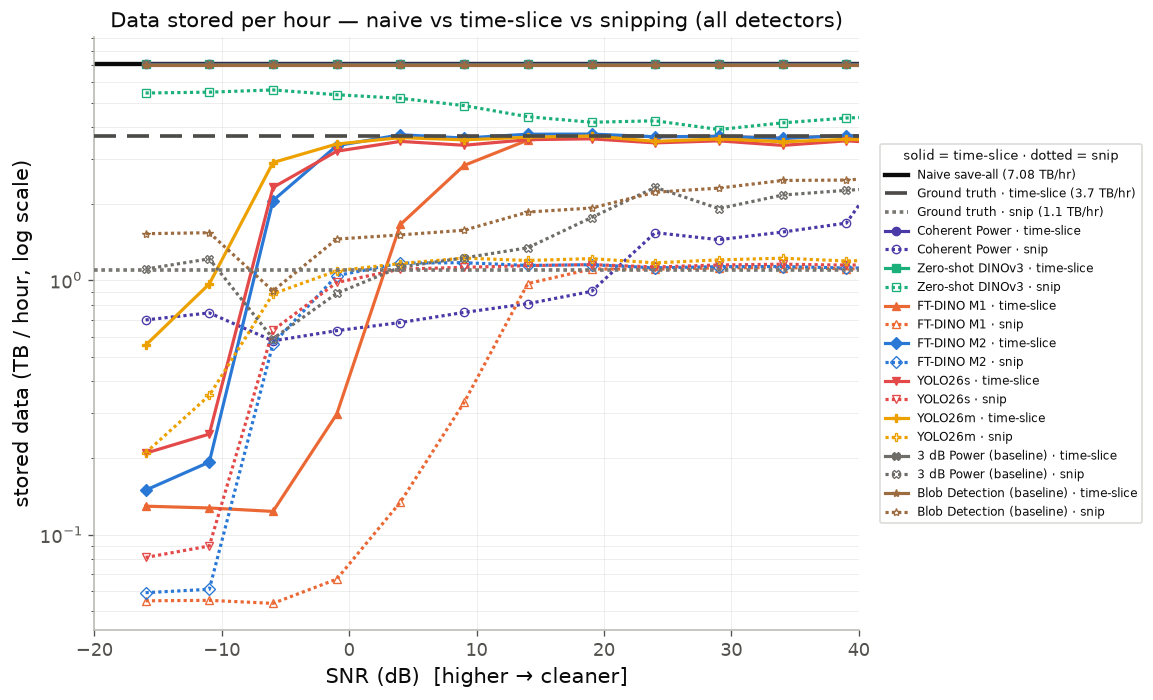

In [6]:
def fig1_all(dets=DETS, fname="fig1_bytes_per_hour.png"):
    fig, ax = plt.subplots(figsize=(9.8, 6.0))
    ax.axhline(SAVE_ALL_BYTES_HR/1e12, color="#0b0b0b", ls="-", lw=2.6, zorder=2,
               label="Naive save-all (7.08 TB/hr)")
    ax.axhline(GT_TS_MEAN_TB, color="#4d4b47", ls=(0, (6, 3)), lw=2.2, zorder=3,
               label=f"Ground truth · time-slice ({GT_TS_MEAN_TB:.1f} TB/hr)")
    ax.axhline(GT_SNIP_MEAN_TB, color="#7a7873", ls=(0, (1, 1)), lw=2.2, zorder=3,
               label=f"Ground truth · snip ({GT_SNIP_MEAN_TB:.1f} TB/hr)")
    for det in dets:
        d = ds[ds.detector == det].sort_values("snr_db")
        ax.plot(d.snr_db, d.timeslice_TB_hr, ls="-", marker=MARKER[det], color=COLOR[det],
                lw=1.9, ms=5, label=f"{LABEL[det]} · time-slice")
        mm = d.dropna(subset=["resample_meas_TB_hr"])
        ax.plot(mm.snr_db, mm.resample_meas_TB_hr, ls=(0, (1, 1)), marker=MARKER[det],
                color=COLOR[det], lw=1.9, ms=5, mfc="none", label=f"{LABEL[det]} · snip")
    ax.set_yscale("log"); ax.set_xlim(-20, 40); ax.set_xlabel("SNR (dB)  [higher → cleaner]")
    ax.set_ylabel("stored data (TB / hour, log scale)"); ax.grid(alpha=.3, which="both")
    ax.set_title("Data stored per hour — naive vs time-slice vs snipping (all detectors)")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, .5), ncol=1, fontsize=7,
              title="solid = time-slice · dotted = snip")
    ax.get_legend().get_title().set_fontsize(8)
    fig.tight_layout(); save_fig(fig, fname); display(fig); plt.close(fig)
fig1_all()

## Figure 2 — time-slice only: naive + ground-truth ceiling + every detector
Isolates the **time-slice** strategy. Flat black = naive save-all; bold gray ★ = **ground truth
(perfect time-slice)** — the least a time-slicing scheme could store while keeping every signal
time-row; colored = each detector's time-slice.

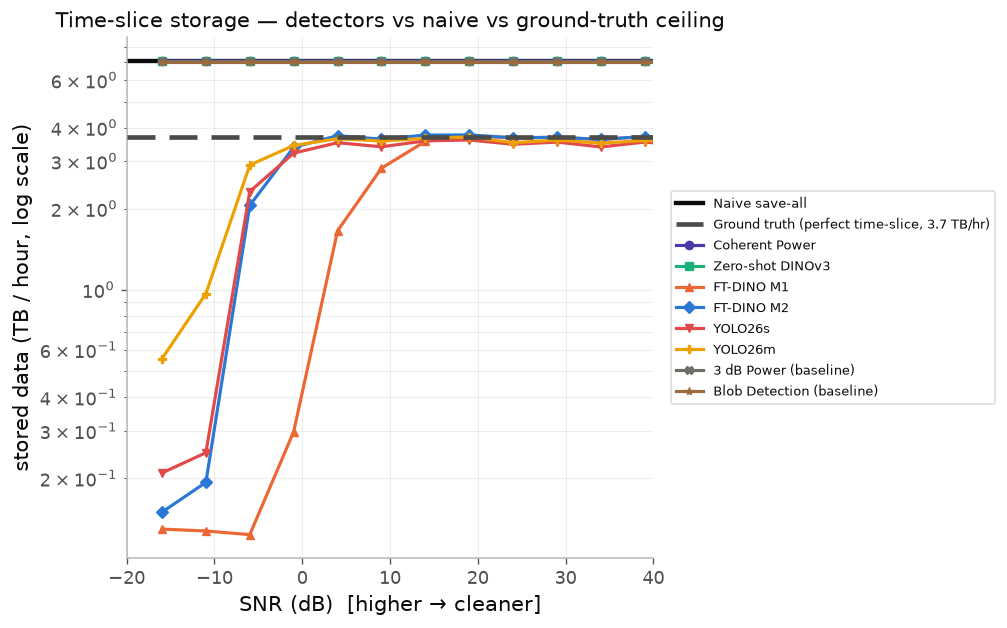

In [7]:
def fig2_timeslice(dets=DETS, fname="fig2_timeslice_bytes.png"):
    fig, ax = plt.subplots(figsize=(8.6, 5.4))
    ax.axhline(SAVE_ALL_BYTES_HR/1e12, color="#0b0b0b", ls="-", lw=2.6, label="Naive save-all")
    ax.axhline(GT_TS_MEAN_TB, color="#4d4b47", ls=(0, (6, 3)), lw=2.8, zorder=5,
               label=f"Ground truth (perfect time-slice, {GT_TS_MEAN_TB:.1f} TB/hr)")
    for det in dets:
        d = ds[ds.detector == det].sort_values("snr_db")
        ax.plot(d.snr_db, d.timeslice_TB_hr, ls="-", marker=MARKER[det], color=COLOR[det],
                lw=1.9, ms=5, label=LABEL[det])
    ax.set_yscale("log"); ax.set_xlim(-20, 40); ax.set_xlabel("SNR (dB)  [higher → cleaner]")
    ax.set_ylabel("stored data (TB / hour, log scale)"); ax.grid(alpha=.3, which="both")
    ax.set_title("Time-slice storage — detectors vs naive vs ground-truth ceiling")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, .5), fontsize=8)
    fig.tight_layout(); save_fig(fig, fname); display(fig); plt.close(fig)
fig2_timeslice()

## Figure 3 — snipping only: naive + ground-truth ceiling + every detector
Isolates the **snipping** (resample+filter) strategy. Flat black = naive save-all; bold gray ★ =
**ground truth (snip)** — the footprint if only the true signals were cut out; colored = each
detector's measured snip footprint (per-box, == the signal_snipper).

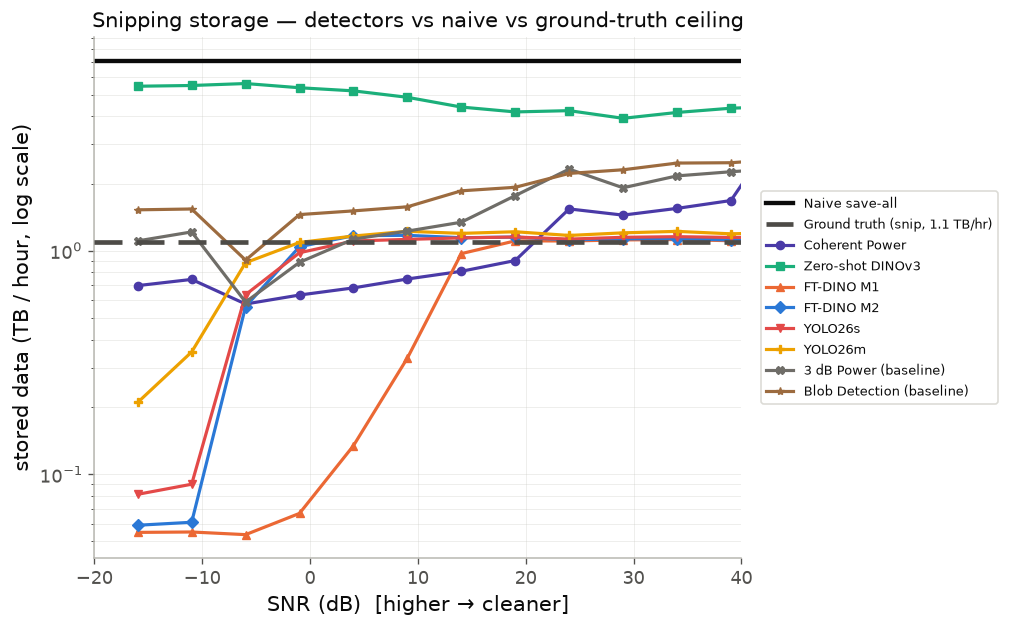

In [8]:
def fig3_snip(dets=DETS, fname="fig3_snip_bytes.png"):
    fig, ax = plt.subplots(figsize=(8.6, 5.4))
    ax.axhline(SAVE_ALL_BYTES_HR/1e12, color="#0b0b0b", ls="-", lw=2.6, label="Naive save-all")
    ax.axhline(GT_SNIP_MEAN_TB, color="#4d4b47", ls=(0, (6, 3)), lw=2.8, zorder=5,
               label=f"Ground truth (snip, {GT_SNIP_MEAN_TB:.1f} TB/hr)")
    for det in dets:
        d = ds[ds.detector == det].dropna(subset=["resample_meas_TB_hr"]).sort_values("snr_db")
        ax.plot(d.snr_db, d.resample_meas_TB_hr, ls="-", marker=MARKER[det], color=COLOR[det],
                lw=1.9, ms=5, label=LABEL[det])
    ax.set_yscale("log"); ax.set_xlim(-20, 40); ax.set_xlabel("SNR (dB)  [higher → cleaner]")
    ax.set_ylabel("stored data (TB / hour, log scale)"); ax.grid(alpha=.3, which="both")
    ax.set_title("Snipping storage — detectors vs naive vs ground-truth ceiling")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, .5), fontsize=8)
    fig.tight_layout(); save_fig(fig, fname); display(fig); plt.close(fig)
fig3_snip()

## Why time-slice barely helps cuda_dino — masks with x = time, y = frequency
A few cuda_dino masks at 45 dB (denoised, as time-slicing sees them). **x = time** (512 rows),
**y = frequency** (10240 bins). A time column is KEPT by time-slicing if it contains ANY detection;
kept time is shaded green. cuda_dino's persistent tone-streaks span nearly the whole timeline, so
~all time columns are kept (timeslice_frac≈1) → time-slicing stores almost the entire capture.
Bottom row = ground truth on the same frames (only the true signal's time is kept) for contrast.

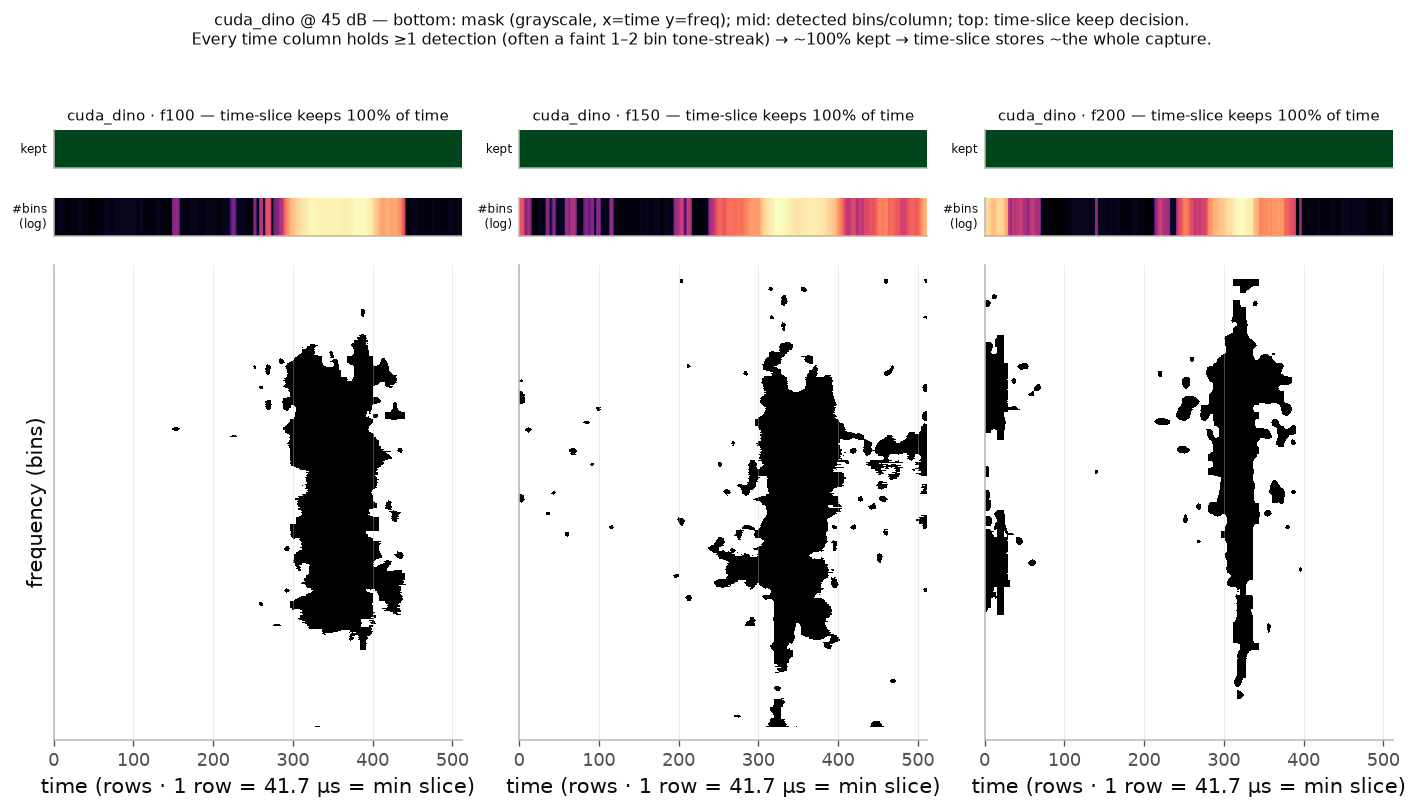

In [9]:
def _cuda_fm(det, stem, f):
    d = SWEEP / det / stem / "mask_arrays"
    c = sorted(d.glob(f"mask_ch0_f{f}_*.packed.npz")) or sorted(d.glob(f"mask_ch0_f{f}_*.npy"))
    return _load(c[0]).astype(bool) if c else None
def _cuda_gm(stem, f):
    d = SWEEP / "cuda_dino" / stem / "gt_masks"
    c = sorted(d.glob(f"*_f{f}_*.packed.npz")) or sorted(d.glob(f"*_f{f}_*.npy"))
    return _load(c[0]).astype(bool) if c else None

def fig_timeslice_cuda_example(stem="attenuation_dB_45", frames=(100, 150, 200),
                               fname="fig_timeslice_cuda_example.png"):
    import matplotlib.gridspec as gridspec
    hop_us = NFFT / RATE_HZ * 1e6                     # one time-row = the min time-slice block
    fig = plt.figure(figsize=(4.8 * len(frames), 6.6))
    gs = gridspec.GridSpec(3, len(frames), height_ratios=[0.32, 0.32, 4.0], hspace=0.16, wspace=0.14)
    for j, fnum in enumerate(frames):
        m = _cuda_fm("cuda_dino", stem, fnum)
        if m is None:
            continue
        md = denoise(m.astype(np.uint8)).astype(bool)
        kept = md.any(axis=1)                          # per time-row: kept by time-slice?
        bins_on = md.sum(axis=1)                        # detected freq-bins in each time column
        frac = float(kept.mean())
        # (top) time-slice KEEP decision — green = kept, white = dropped (this is separate from the mask)
        axk = fig.add_subplot(gs[0, j])
        axk.imshow(kept[None, :], aspect="auto", cmap="Greens", vmin=0, vmax=1,
                   extent=[0, md.shape[0], 0, 1], interpolation="nearest")
        axk.set_yticks([]); axk.set_xticks([])
        axk.set_title(f"cuda_dino · f{fnum} — time-slice keeps {frac*100:.0f}% of time", fontsize=9)
        axk.set_ylabel("kept", fontsize=7, rotation=0, ha="right", va="center")
        # (mid) detected freq-bins per time column (log) — reveals the faint thin tone-streaks
        axc = fig.add_subplot(gs[1, j])
        axc.imshow(np.log10(bins_on[None, :] + 1.0), aspect="auto", cmap="magma",
                   extent=[0, md.shape[0], 0, 1], interpolation="nearest")
        axc.set_yticks([]); axc.set_xticks([])
        axc.set_ylabel("#bins\n(log)", fontsize=7, rotation=0, ha="right", va="center")
        # (bottom) the actual mask, x = time, y = frequency (grayscale ONLY — no green here)
        axm = fig.add_subplot(gs[2, j])
        axm.imshow(md.T, aspect="auto", cmap="Greys", origin="lower", interpolation="nearest",
                   extent=[0, md.shape[0], 0, md.shape[1]])
        axm.set_xlabel(f"time (rows · 1 row = {hop_us:.1f} µs = min slice)")
        axm.set_yticks([])
        if j == 0:
            axm.set_ylabel("frequency (bins)")
    fig.suptitle("cuda_dino @ 45 dB — bottom: mask (grayscale, x=time y=freq); mid: detected bins/column; "
                 "top: time-slice keep decision.\nEvery time column holds ≥1 detection (often a faint 1–2 bin "
                 "tone-streak) → ~100% kept → time-slice stores ~the whole capture.", y=1.03, fontsize=9.5)
    fig.tight_layout(); save_fig(fig, fname); display(fig); plt.close(fig)
fig_timeslice_cuda_example()

## Figure — reduction vs retention (the honest trade-off)
Saving bytes by dropping un-flagged data only helps if the *signal* is kept. X = data-reduction
factor (× vs save-all, time-slice strategy); Y = signal-time retention. Up-and-right is better.

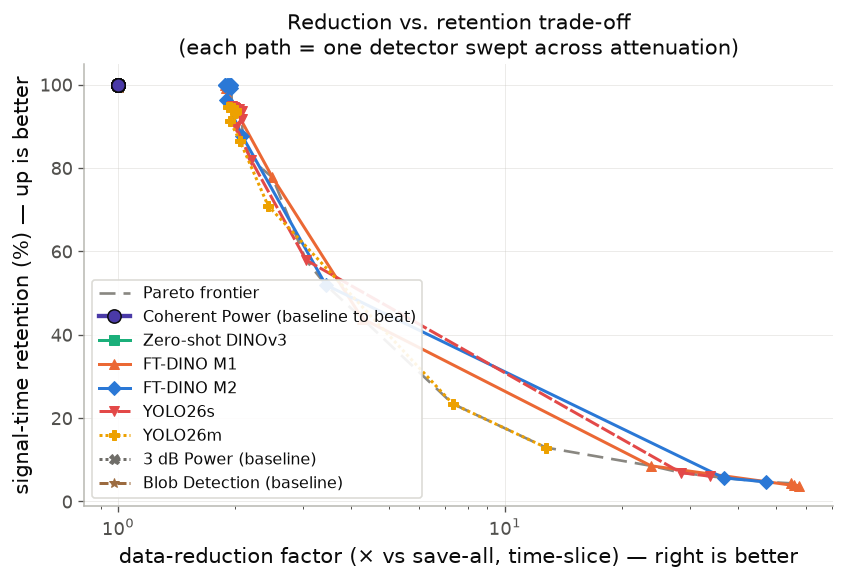

In [10]:
def _pareto_frontier(x, y):
    """Return frontier points (max x AND max y are both 'good') sorted by x."""
    pts = sorted(zip(x, y), key=lambda p: (-p[0], -p[1]))   # by decreasing reduction
    front, best_y = [], -np.inf
    for px, py in pts:                                       # sweep high->low reduction
        if py > best_y:                                      # keeps a higher retention than any so-far
            front.append((px, py)); best_y = py
    return np.array(sorted(front))

def fig_tradeoff(fname="fig_reduction_vs_retention.png"):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    g = ds.dropna(subset=["retention"])
    fr = _pareto_frontier(g.reduction_x.values, 100*g.retention.values)
    if len(fr):
        ax.plot(fr[:, 0], fr[:, 1], color="#898781", lw=1.6, ls=(0, (6, 3)), zorder=1,
                label="Pareto frontier")
    for det in DETS:
        d = ds[ds.detector == det].sort_values("attenuation_db")
        base = det == "coherent_power"
        ax.plot(d.reduction_x, 100*d.retention, ls=DASH[det], marker=MARKER[det], color=COLOR[det],
                lw=2.6 if base else 1.8, ms=8 if base else 6, zorder=4 if base else 3,
                mec="#0b0b0b" if base else COLOR[det], mew=0.9 if base else 0.6,
                label=("Coherent Power (baseline to beat)" if base else LABEL[det]))
    ax.set_xscale("log")
    ax.set_xlabel("data-reduction factor (× vs save-all, time-slice) — right is better")
    ax.set_ylabel("signal-time retention (%) — up is better")
    ax.set_title("Reduction vs. retention trade-off\n(each path = one detector swept across attenuation)")
    ax.legend(loc="lower left"); fig.tight_layout()
    save_fig(fig, fname); display(fig); plt.close(fig)
fig_tradeoff()

## Figure — reduction vs retention vs *accuracy of retention* (trajectory-bubble)
Adds the 3rd axis via color = **pixel-IoU** (how tightly the kept mask matches GT). Each detector
is a path across SNR; color tells you whether what it kept was actually accurate.

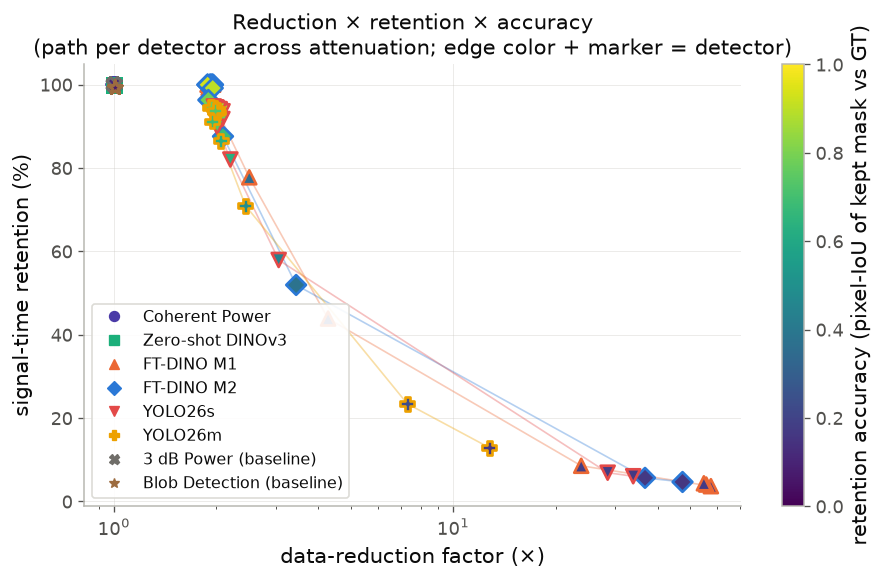

In [11]:
frame = pd.read_csv(TABLES/"frame_pixel_metrics.csv")
iou_by = (frame.groupby(["detector","attenuation_db"])["iou"].mean().reset_index()
          .rename(columns={"iou":"pixel_iou"}))
ds = ds.merge(iou_by, on=["detector","attenuation_db"], how="left")

def fig_bubble(fname="fig_reduction_retention_accuracy.png"):
    fig, ax = plt.subplots(figsize=(7.8, 5.0))
    sc = None
    for det in DETS:
        d = ds[ds.detector == det].sort_values("attenuation_db")
        ax.plot(d.reduction_x, 100*d.retention, "-", color=COLOR[det], alpha=.35, lw=1)
        sc = ax.scatter(d.reduction_x, 100*d.retention, c=d.pixel_iou, cmap="viridis",
                        vmin=0, vmax=1, s=70, marker=MARKER[det],
                        edgecolor=COLOR[det], linewidth=1.6, zorder=3)
    if sc is not None:
        cb = fig.colorbar(sc, ax=ax); cb.set_label("retention accuracy (pixel-IoU of kept mask vs GT)")
    ax.set_xscale("log")
    ax.set_xlabel("data-reduction factor (×)"); ax.set_ylabel("signal-time retention (%)")
    ax.set_title("Reduction × retention × accuracy\n(path per detector across attenuation; edge color + marker = detector)")
    handles = [plt.Line2D([], [], color=COLOR[d], marker=MARKER[d], ls='', label=LABEL[d]) for d in DETS]
    ax.legend(handles=handles, loc="lower left"); fig.tight_layout()
    save_fig(fig, fname); display(fig); plt.close(fig)
fig_bubble()

## Figure — signal-retention (fidelity) vs SNR, per detector
The fidelity side of the trade-off on its own axis: of a signal's occupied time-rows, the fraction
the detector still flags (so that 42-µs slot is kept). **Coherent Power is the baseline to beat** —
it is *supposed* to emit a mask even if unoptimized, so any learned detector should sit above it.

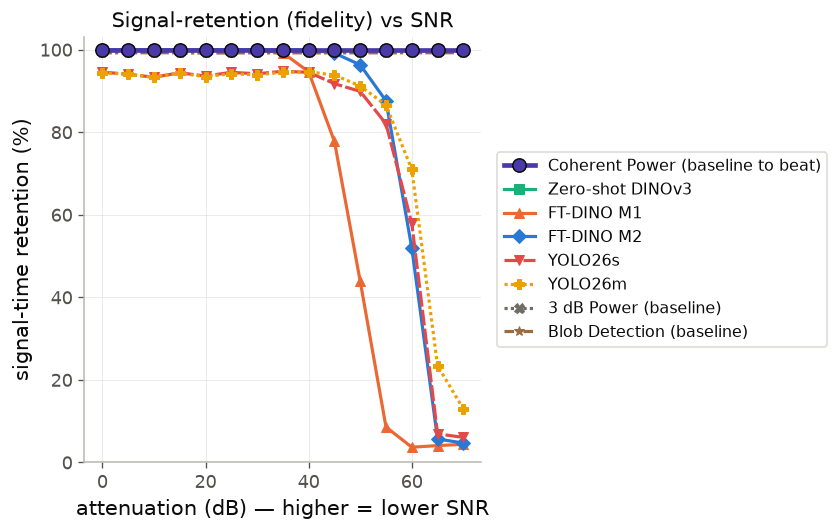

In [12]:
def fig_retention(fname="fig_retention_vs_snr.png"):
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    for det in DETS:
        d = ds[ds.detector == det].sort_values("attenuation_db")
        base = det == "coherent_power"
        ax.plot(d.attenuation_db, 100*d.retention, ls=DASH[det], marker=MARKER[det], color=COLOR[det],
                lw=2.8 if base else 1.9, ms=8 if base else 6, zorder=5 if base else 3,
                mec="#0b0b0b" if base else COLOR[det], mew=0.9 if base else 0.6,
                label=("Coherent Power (baseline to beat)" if base else LABEL[det]))
    ax.set_ylim(0, 103); ax.set_xlabel("attenuation (dB) — higher = lower SNR")
    ax.set_ylabel("signal-time retention (%)")
    ax.set_title("Signal-retention (fidelity) vs SNR")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, .5)); fig.tight_layout()
    save_fig(fig, fname); display(fig); plt.close(fig)
fig_retention()

## 2. Compute cost (FLOPs + GPU memory + real-time throughput)
From `compute_table.csv`. `realtime_x` = sustained throughput ÷ the 938 tiles/s needed to keep up
with 245.76 MS/s (≥1 = real-time capable on one GPU). Coherent/zero-shot are estimates.

,model,params_M,gflops_per_tile,gflops_per_s_realtime,gpu_mem_mb,realtime_x,src
0,finetuned_dino_m1,87.6,91.43,85715.6,512,0.091,offline
1,finetuned_dino_m2,87.6,91.43,85715.6,511,0.091,offline
2,cuda_dino_zeroshot,87.6,91.43,85715.6,512,0.091,container(est)
3,yolo26m,20.4,173.69,162834.4,662,0.171,offline
4,coherent_power,0.0,0.01,9.4,50,inf,container(est)
5,yolo26s,9.5,52.54,49256.2,178,0.221,offline


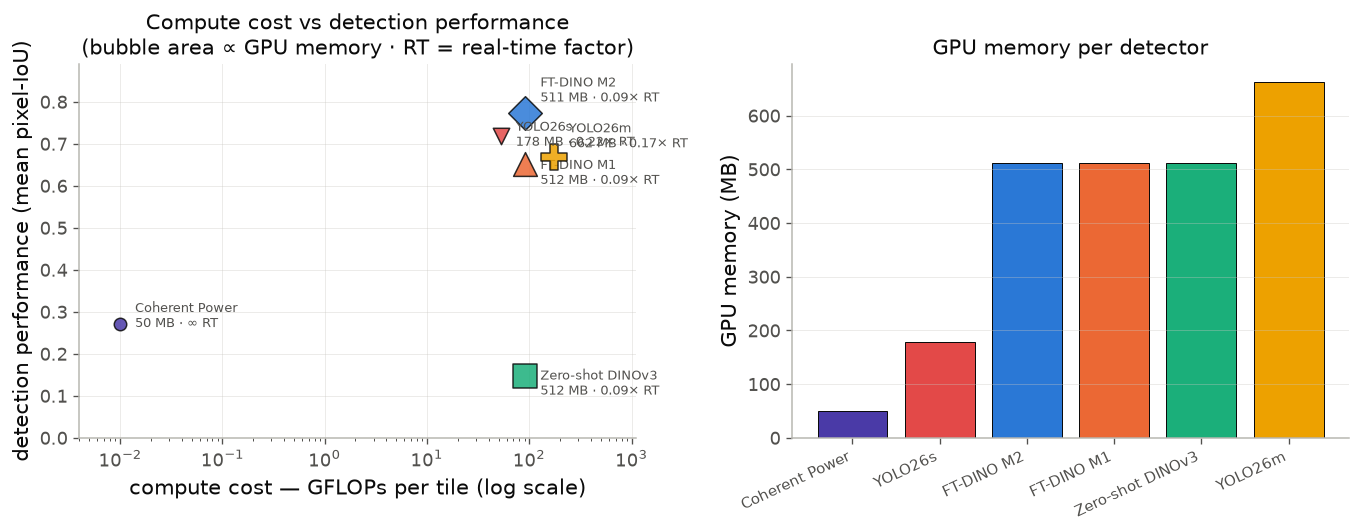

In [13]:
comp = pd.read_csv(COMPUTE_CSV)
display(comp[["model","params_M","gflops_per_tile","gflops_per_s_realtime","gpu_mem_mb","realtime_x","src"]])

# map compute-table model names -> detector keys used everywhere else
_COMP2DET = {"finetuned_dino_m1":"finetuned_dino","finetuned_dino_m2":"finetuned_dino_m2",
             "cuda_dino_zeroshot":"cuda_dino","yolo26m":"yolo26m","yolo26s":"yolo26s",
             "coherent_power":"coherent_power"}
comp["detector"] = comp.model.map(_COMP2DET)
# detection performance = mean pixel-IoU across the SNR sweep (one scalar per detector)
_perf = ds.groupby("detector").pixel_iou.mean()
comp["mean_iou"] = comp.detector.map(_perf)
cc = comp.dropna(subset=["detector"]).copy()

# per-detector text offsets (points) so the clustered ViT-B labels don't collide
_CMP_OFF = {"coherent_power":(9,-2),"cuda_dino":(9,-11),"finetuned_dino":(9,-12),
            "finetuned_dino_m2":(9,7),"yolo26m":(9,6),"yolo26s":(9,-6)}
def fig_compute(fname="fig_compute.png"):
    fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.6))
    # (a) compute cost (GFLOPs/tile, log) vs detection performance (mean IoU); bubble = GPU memory
    for _, r in cc.iterrows():
        det = r.detector
        ax[0].scatter(r.gflops_per_tile, r.mean_iou, s=40 + r.gpu_mem_mb*0.32,
                      color=COLOR[det], marker=MARKER[det], edgecolor="#0b0b0b",
                      linewidth=0.9, alpha=.85, zorder=3)
        rt = "∞" if not np.isfinite(r.realtime_x) else f"{r.realtime_x:.2f}×"
        ax[0].annotate(f"{LABEL.get(det, det)}\n{r.gpu_mem_mb:.0f} MB · {rt} RT",
                       (r.gflops_per_tile, r.mean_iou), textcoords="offset points",
                       xytext=_CMP_OFF.get(det, (9, 6)), fontsize=7.5, color="#52514e")
    ax[0].set_xscale("log"); ax[0].set_xlim(4e-3, 1.1e3)
    ax[0].set_xlabel("compute cost — GFLOPs per tile (log scale)")
    ax[0].set_ylabel("detection performance (mean pixel-IoU)")
    ax[0].set_title("Compute cost vs detection performance\n(bubble area ∝ GPU memory · RT = real-time factor)")
    ax[0].set_ylim(0, max(0.5, cc.mean_iou.max()*1.15))
    # (b) GPU memory bar, colored per detector
    cb = cc.sort_values("gpu_mem_mb")
    ax[1].bar(range(len(cb)), cb.gpu_mem_mb, color=[COLOR[d] for d in cb.detector],
              edgecolor="#0b0b0b", linewidth=0.6)
    ax[1].set_xticks(range(len(cb))); ax[1].set_xticklabels([LABEL[d] for d in cb.detector],
                                                            rotation=25, ha="right", fontsize=9)
    ax[1].set_ylabel("GPU memory (MB)"); ax[1].set_title("GPU memory per detector")
    ax[1].grid(axis="x", visible=False)
    fig.tight_layout(); save_fig(fig, fname); display(fig); plt.close(fig)
fig_compute()

## Figure 2 — detection performance (IoU) vs SNR, paired with compute cost
Model pixel-IoU vs attenuation (line per model); compute table above is the cost side of the trade-off.

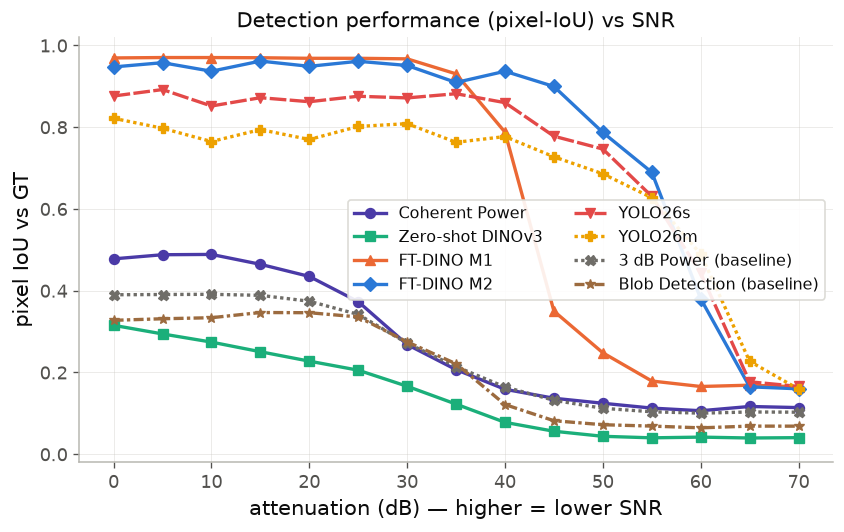

In [14]:
def fig2(fname="fig2_iou_vs_snr.png"):
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    for det in DETS:
        d = ds[ds.detector == det].sort_values("attenuation_db")
        ax.plot(d.attenuation_db, d.pixel_iou, ls=DASH[det], marker=MARKER[det],
                color=COLOR[det], label=LABEL[det])
    ax.set_xlabel("attenuation (dB) — higher = lower SNR"); ax.set_ylabel("pixel IoU vs GT")
    ax.set_ylim(-.02, 1.02); ax.legend(ncol=2)
    ax.set_title("Detection performance (pixel-IoU) vs SNR")
    fig.tight_layout(); save_fig(fig, fname); display(fig); plt.close(fig)
fig2()

## Extra — the real-time benefit vs naive capture-everything
Cumulative TB/hour saved by time-slicing (per detector), i.e. `SAVE_ALL − time-slice`.

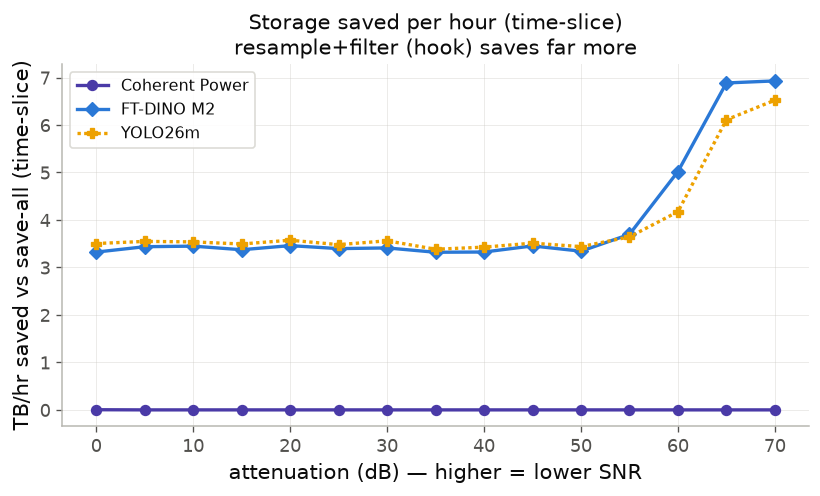

In [15]:
def fig_saved(fname="fig_tb_saved.png"):
    fig, ax = plt.subplots(figsize=(7.0, 4.3))
    for det in ("coherent_power","finetuned_dino_m2","yolo26m"):
        d=ds[ds.detector==det].sort_values("attenuation_db")
        ax.plot(d.attenuation_db, d.saveall_TB_hr-d.timeslice_TB_hr, ls=DASH[det],
                marker=MARKER[det], color=COLOR[det], label=LABEL[det])
    ax.set_xlabel("attenuation (dB) — higher = lower SNR")
    ax.set_ylabel("TB/hr saved vs save-all (time-slice)")
    ax.set_title("Storage saved per hour (time-slice)\nresample+filter (hook) saves far more")
    ax.legend(); fig.tight_layout()
    save_fig(fig, fname); display(fig); plt.close(fig)
fig_saved()

## Figure 3 — LIVE OTA data (dense bursty 2.4 GHz traffic)
On-the-air capture at **2.45 GHz center, 200 MHz BW** (WiFi/BLE — dense, bursty). Bars: naive +
5 detectors; y = **stored bytes/hour (log)** via time-slicing. Dense traffic = little signal-free
time, so time-slicing saves *less* here (bars sit near naive) — motivating the resample+filter
(frequency) approach. `coherent_power` + zero-shot DINO are container-only (no live masks) → hatched
"pending". No ground truth on live data, so this is stored-bytes only (no retention).

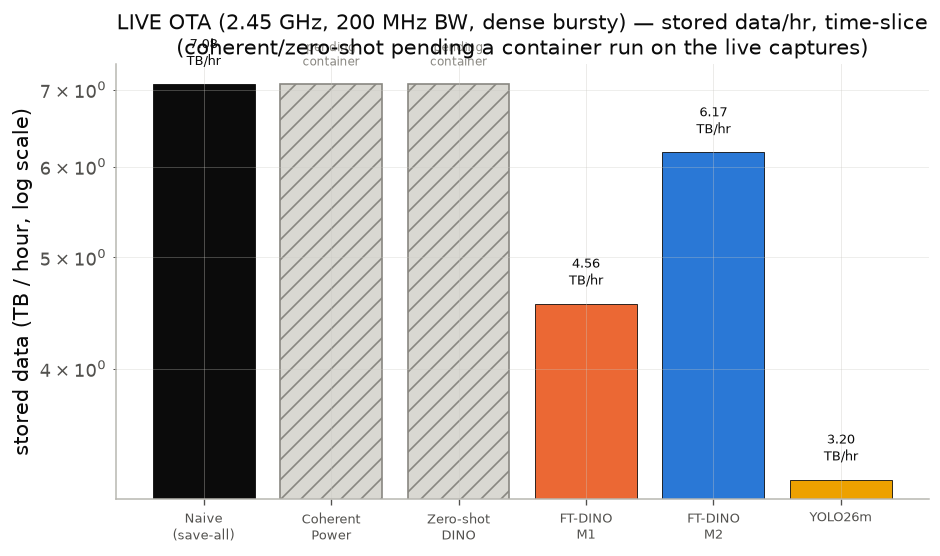

In [16]:
live = pd.read_csv("live_data_saving.csv")
_order = ["naive_save_all","coherent_power","cuda_dino_zeroshot","finetuned_dino","finetuned_dino_m2","yolo26m"]
live = live.set_index("model").reindex(_order).reset_index()
_lab = {"naive_save_all":"Naive\n(save-all)","coherent_power":"Coherent\nPower","cuda_dino_zeroshot":"Zero-shot\nDINO",
        "finetuned_dino":"FT-DINO\nM1","finetuned_dino_m2":"FT-DINO\nM2","yolo26m":"YOLO26m"}
_OTA2DET = {"cuda_dino_zeroshot":"cuda_dino"}   # live model key -> COLOR key
def _ota_color(m):
    return COLOR.get(_OTA2DET.get(m, m), "#52514e")
def fig3(fname="fig3_live_ota_bytes.png"):
    fig, ax = plt.subplots(figsize=(8.0, 4.8)); base = SAVE_ALL_BYTES_HR/1e12
    for i, r in live.iterrows():
        v = r.stored_TB_hr_timeslice
        if r.status == "pending(container)" or not np.isfinite(v):
            ax.bar(i, base, color="#d9d8d2", hatch="//", edgecolor="#898781")
            ax.text(i, base*1.03, "pending\ncontainer", ha="center", va="bottom", fontsize=7, color="#898781")
        else:
            ax.bar(i, v, color=("#0b0b0b" if r.model=="naive_save_all" else _ota_color(r.model)),
                   edgecolor="#0b0b0b", linewidth=0.5)
            ax.text(i, v*1.03, f"{v:.2f}\nTB/hr", ha="center", va="bottom", fontsize=8)
    ax.set_yscale("log"); ax.set_xticks(range(len(live))); ax.set_xticklabels([_lab[m] for m in live.model], fontsize=8)
    ax.set_ylabel("stored data (TB / hour, log scale)")
    ax.set_title("LIVE OTA (2.45 GHz, 200 MHz BW, dense bursty) — stored data/hr, time-slice\n(coherent/zero-shot pending a container run on the live captures)")
    ax.grid(alpha=.3, axis="y", which="both"); fig.tight_layout()
    save_fig(fig, fname); display(fig); plt.close(fig)
fig3()

Variation: time-slice vs resample+filter (projected) on the OTA data, per offline model.

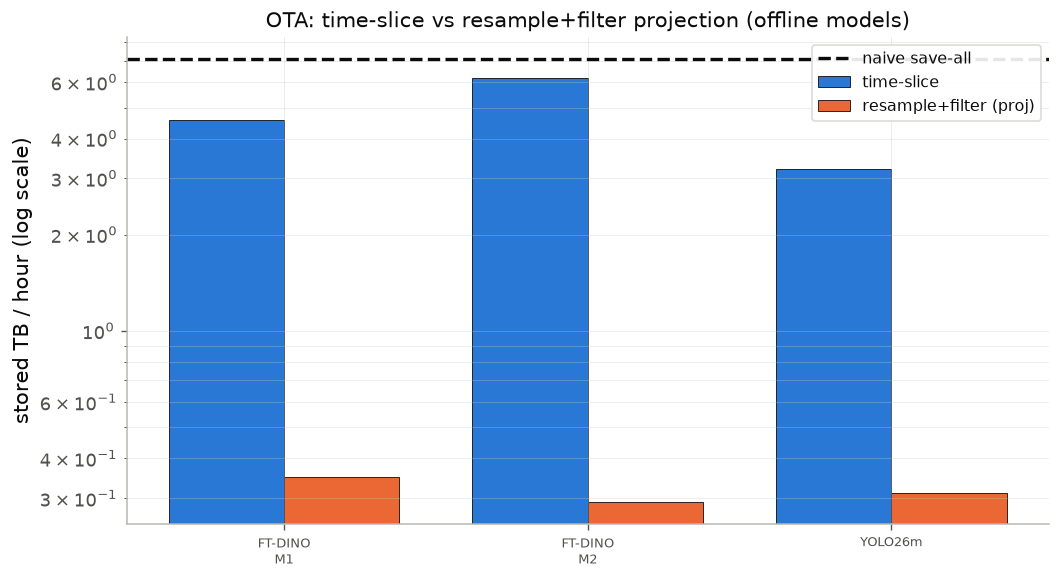

In [17]:
def fig3b(fname="fig3b_live_ota_resample.png"):
    av = live[live.status == "offline"]; xs = np.arange(len(av)); w = 0.38
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(xs-w/2, av.stored_TB_hr_timeslice, w, label="time-slice", color="#2a78d6", edgecolor="#0b0b0b", linewidth=0.5)
    ax.bar(xs+w/2, av.stored_TB_hr_resample_proj, w, label="resample+filter (proj)", color="#eb6834", edgecolor="#0b0b0b", linewidth=0.5)
    ax.axhline(SAVE_ALL_BYTES_HR/1e12, color="#0b0b0b", ls="--", label="naive save-all")
    ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xticklabels([_lab[m] for m in av.model], fontsize=8)
    ax.set_ylabel("stored TB / hour (log scale)"); ax.set_title("OTA: time-slice vs resample+filter projection (offline models)")
    ax.legend(); ax.grid(alpha=.3, axis="y", which="both"); fig.tight_layout()
    save_fig(fig, fname); display(fig); plt.close(fig)
fig3b()

## Figure 3c — OTA resample+filter **MEASURED** (real signal_snipper output)
Bars = actual snipped-SigMF bytes/hr from running `signal_snipper` (frequency mode) offline over the
live captures, vs the raw-mask-coverage projection. A model shows a measured bar only once its snipper
run exists under `SNIP_ROOT/<detector>/<stem>/snippets/`; otherwise it is hatched "pending(snipper)".
Run: `sudo env CONTAINER_NAME=<container> applications/usrp_wideband_signal_detection/bash_scripts/run_offline_snipper.sh`
(add `DETECTOR=cuda_dino` for the zero-shot DINO masks), then re-run this notebook.

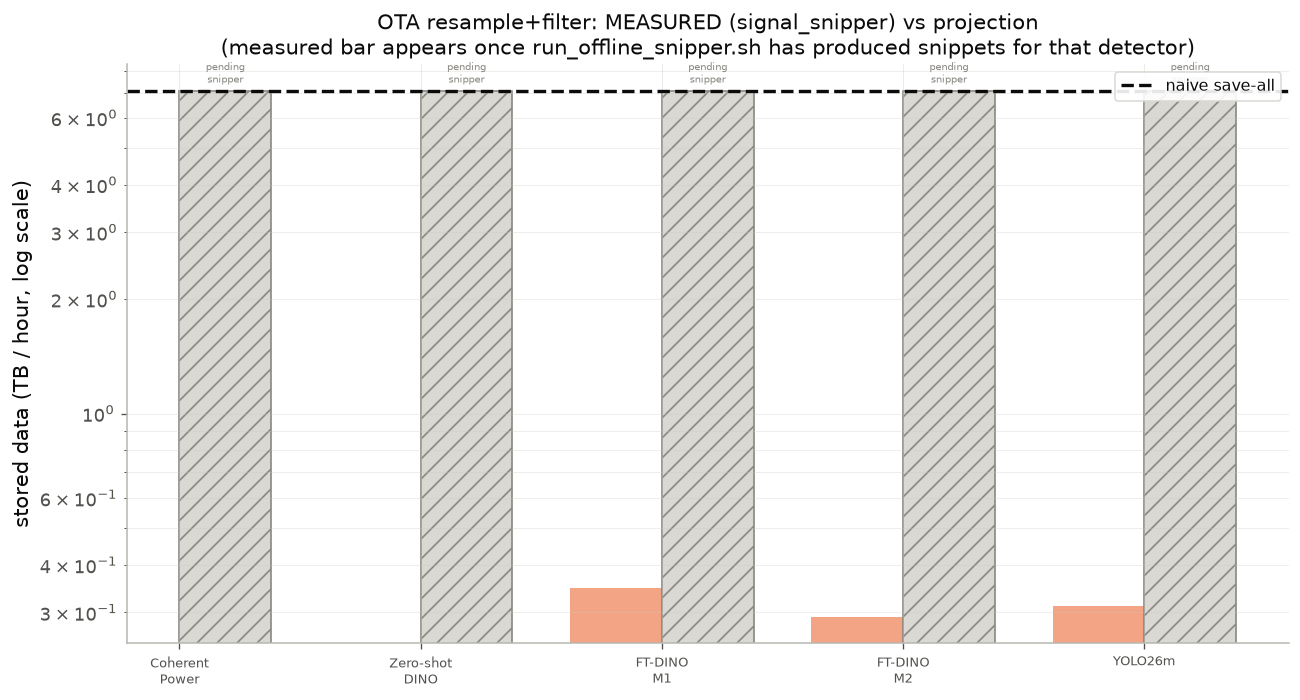

fig3c: measured resample+filter for 0/5 models (run bash_scripts/run_offline_snipper.sh for the rest)


In [18]:
OTA_STEMS   = os.environ.get("DS_OTA_STEMS", "test_1,test_2,test_3").split(",")
OTA_CAP_SEC = float(os.environ.get("DS_OTA_CAP_SEC", "3.0"))   # 5.9 GB cf32 @ 245.76 MS/s = 3.0 s/file
_snip_det   = {"coherent_power":"coherent_power","cuda_dino_zeroshot":"cuda_dino",
               "finetuned_dino":"finetuned_dino","finetuned_dino_m2":"finetuned_dino_m2","yolo26m":"yolo26m"}

def ota_resample_meas_TB_hr(model):
    det = _snip_det.get(model)
    if det is None:
        return np.nan
    tot, found = 0, False
    for st in OTA_STEMS:
        b = snippet_bytes(det, st)
        if b is not None:
            tot += b; found = True
    return (tot / (OTA_CAP_SEC * len(OTA_STEMS)) * SEC_PER_HR / 1e12) if found else np.nan

def fig3c(fname="fig3c_live_ota_resample_measured.png"):
    models = [m for m in _order if m != "naive_save_all"]
    xs, w = np.arange(len(models)), 0.38
    fig, ax = plt.subplots(figsize=(11, 6))
    meas = {m: ota_resample_meas_TB_hr(m) for m in models}
    proj = {r.model: r.get("stored_TB_hr_resample_proj", np.nan) for _, r in live.iterrows()}
    for i, m in enumerate(models):
        pv = proj.get(m, np.nan)
        if np.isfinite(pv):
            ax.bar(xs[i]-w/2, pv, w, color="#eb6834", alpha=.6,
                   label=("resample+filter (proj)" if i == 0 else None))
        mv = meas[m]
        if np.isfinite(mv):
            ax.bar(xs[i]+w/2, mv, w, color="#2a78d6", edgecolor="#0b0b0b", linewidth=0.5,
                   label=("resample+filter (MEASURED)" if i == 0 else None))
            ax.text(xs[i]+w/2, mv*1.05, f"{mv:.3g}", ha="center", va="bottom", fontsize=7)
        else:
            ax.bar(xs[i]+w/2, SAVE_ALL_BYTES_HR/1e12, w, color="#d9d8d2", hatch="//", edgecolor="#898781")
            ax.text(xs[i]+w/2, (SAVE_ALL_BYTES_HR/1e12)*1.03, "pending\nsnipper",
                    ha="center", va="bottom", fontsize=6, color="#898781")
    ax.axhline(SAVE_ALL_BYTES_HR/1e12, color="#0b0b0b", ls="--", label="naive save-all")
    ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xticklabels([_lab[m] for m in models], fontsize=8)
    ax.set_ylabel("stored data (TB / hour, log scale)")
    ax.set_title("OTA resample+filter: MEASURED (signal_snipper) vs projection\n"
                 "(measured bar appears once run_offline_snipper.sh has produced snippets for that detector)")
    ax.legend(loc="upper right"); ax.grid(alpha=.3, axis="y", which="both"); fig.tight_layout()
    save_fig(fig, fname); display(fig); plt.close(fig)
    n_meas = sum(np.isfinite(v) for v in meas.values())
    print(f"fig3c: measured resample+filter for {n_meas}/{len(models)} models "
          f"({'run bash_scripts/run_offline_snipper.sh for the rest' if n_meas < len(models) else 'all present'})")
fig3c()

## Caveats & hooks
1. **Resample+filter has two forms here.** Figures 1/3b use a *projection* (raw-mask TF-coverage);
   Figure 3c uses the **measured** `signal_snipper` output via `resample_filter_bytes_per_hour(detector,
   stem, capture_sec)` (now wired to the real operator, not a stub). Produce measurements with
   `applications/usrp_wideband_signal_detection/bash_scripts/run_offline_snipper.sh` (container/lab-admin),
   then re-run — measured bars replace the "pending(snipper)" placeholders.
2. **Metrics are on the DENOISED mask** (components < `MIN_BOX_PIXELS`=256 dropped, matching the
   snipper). Raw "any on-pixel per row" over-counts speckle: at high attenuation it kept ~all the
   time (see `fig_timeslice_raw_vs_denoised`). Denoising fixes coherent_power (att 60: keep ~0.47 -> ~0.02);
   cuda_dino still keeps ~all the time from persistent tone-streaks (a real zero-shot property).
   **Retention is time-based** (fraction of the signal's time-rows kept); coherent-power is the baseline
   to beat. Time-slice granularity is a knob (`timeslice_frac(block_rows=...)`).
3. **Compute FLOPs are estimates** (ViT-B scaled for DINO, ultralytics for YOLO, FFT for coherent);
   GPU memory measured for the offline models; container detectors (coherent, zero-shot) estimated.
4. Numbers use `DS_NFRAMES` frames/stem (default 120); set higher for the final figures.

## Detection example — per-model masks on ONE frame (clean detections vs speckle)
For a single frame of one capture, each detector's binary mask (x = freq bins, y = time rows) with
its **final detection boxes** drawn (the snipper's rule: 4-connected components ≥ `MIN_BOX_PIXELS`=256,
then coalesced within a gap). Each title reports **# detection boxes** and **# raw connected-components**.
The gap between those two numbers is the story: "noisy" detectors (`3dB_power`, `coherent_power`) fire
on *thousands of single-pixel specks* (raw CCs) that the min-box filter discards — only a few real
boxes survive — while the fine-tuned models fire a handful of large, clean regions. Choose the example
with `DS_EXAMPLE_STEM` / `DS_EXAMPLE_FRAME`.

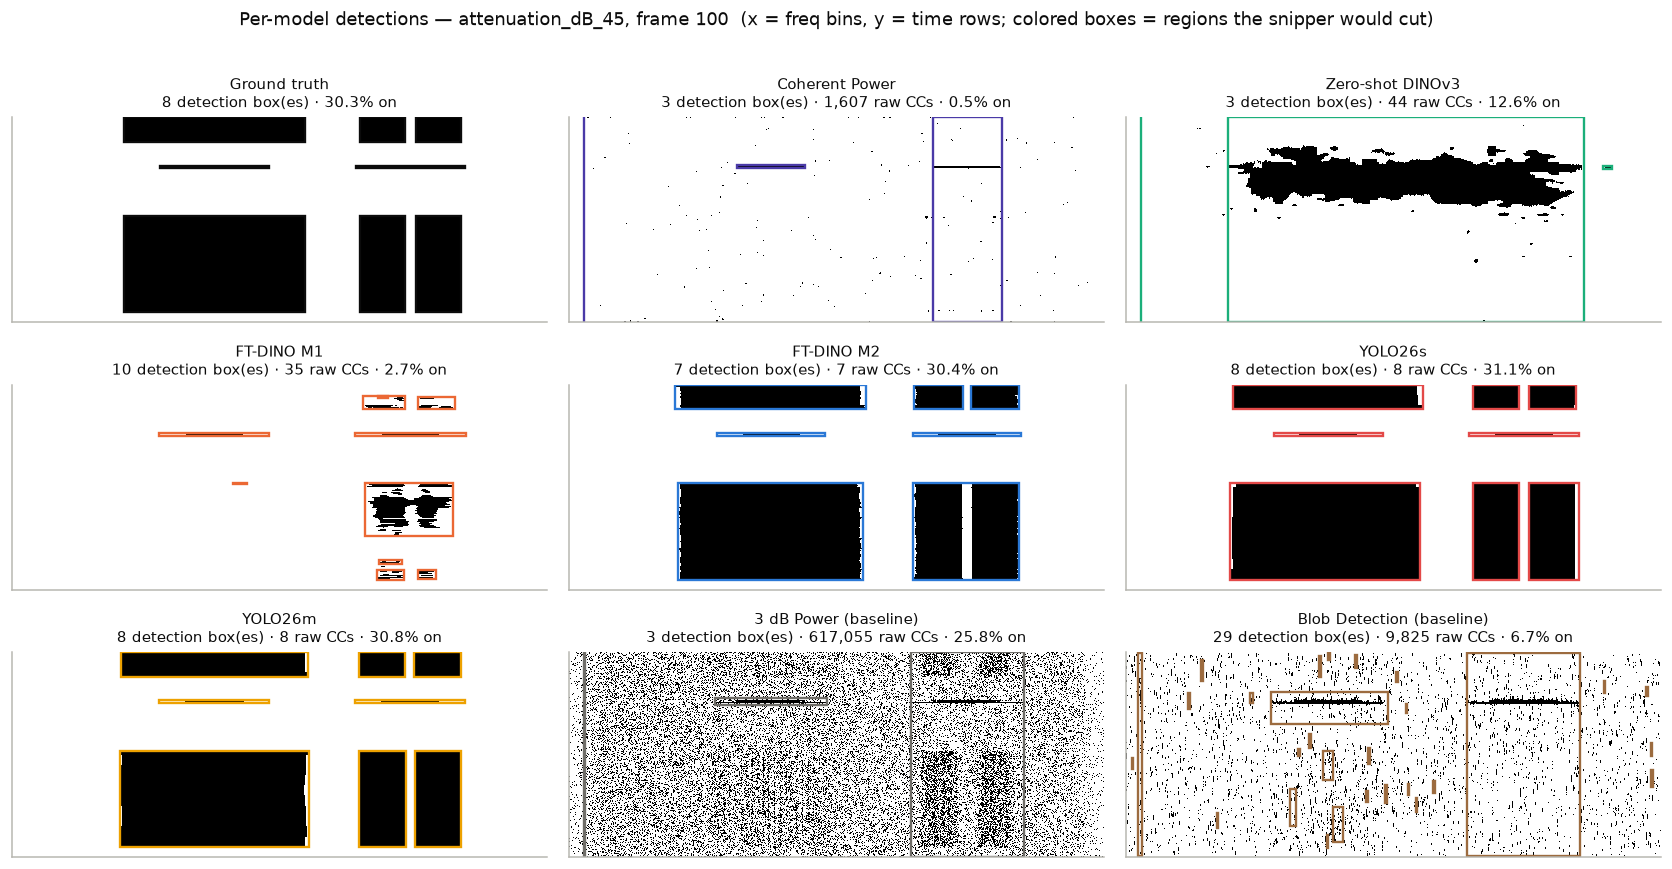

detection boxes on attenuation_dB_45 f100:
  Coherent Power                  3 boxes   (   1,607 raw CCs,   0.5% on)
  Zero-shot DINOv3                3 boxes   (      44 raw CCs,  12.6% on)
  FT-DINO M1                     10 boxes   (      35 raw CCs,   2.7% on)
  FT-DINO M2                      7 boxes   (       7 raw CCs,  30.4% on)
  YOLO26s                         8 boxes   (       8 raw CCs,  31.1% on)
  YOLO26m                         8 boxes   (       8 raw CCs,  30.8% on)
  3 dB Power (baseline)           3 boxes   ( 617,055 raw CCs,  25.8% on)
  Blob Detection (baseline)      29 boxes   (   9,825 raw CCs,   6.7% on)


In [19]:
import sys as _sys
_SNIP = str(HSD / "applications/usrp_wideband_signal_detection/infocom_evals/snip_eval")
if _SNIP not in _sys.path:
    _sys.path.insert(0, _SNIP)
from snip_annotations import boxes_from_mask as _boxes_from_mask   # exact snipper clustering rule
from matplotlib.patches import Rectangle as _Rect

EX_STEM  = os.environ.get("DS_EXAMPLE_STEM", "attenuation_dB_45")
EX_FRAME = int(os.environ.get("DS_EXAMPLE_FRAME", "100"))

def _frame_mask(det, stem, fnum):
    d = SWEEP / det / stem / "mask_arrays"
    c = sorted(d.glob(f"mask_ch0_f{fnum}_*.packed.npz")) or sorted(d.glob(f"mask_ch0_f{fnum}_*.npy"))
    return _load(c[0]).astype(bool) if c else None

def _gt_mask(stem, fnum):
    for det in DETS:
        d = SWEEP / det / stem / "gt_masks"
        c = sorted(d.glob(f"*_f{fnum}_*.packed.npz")) or sorted(d.glob(f"*_f{fnum}_*.npy"))
        if c:
            return _load(c[0]).astype(bool)
    return None

def fig_detection_example(stem=EX_STEM, fnum=EX_FRAME, dets=DETS, fname="fig_detection_example.png"):
    panels = [("__gt__", _gt_mask(stem, fnum))] + [(d, _frame_mask(d, stem, fnum)) for d in dets]
    panels = [(k, m) for k, m in panels if m is not None]
    ncol = 3; nrow = int(np.ceil(len(panels) / ncol))
    fig, axs = plt.subplots(nrow, ncol, figsize=(4.7 * ncol, 2.4 * nrow))
    axs = np.array(axs).reshape(-1)
    summary = []
    for ax, (key, m) in zip(axs, panels):
        ax.imshow(m, aspect="auto", cmap="Greys", origin="lower", interpolation="nearest",
                  extent=[0, m.shape[1], 0, m.shape[0]])
        boxes = _boxes_from_mask(m, MIN_BOX_PIXELS, 16, 80)
        if key == "__gt__":
            col, lab, extra = "#0b0b0b", "Ground truth", f"{m.mean()*100:.1f}% on"
        else:
            col, lab = COLOR[key], LABEL[key]
            _, nraw = ndimage.label(m)
            extra = f"{nraw:,} raw CCs · {m.mean()*100:.1f}% on"
            summary.append((lab, len(boxes), nraw, m.mean()*100))
        for (r0, r1, c0, c1) in boxes:
            ax.add_patch(_Rect((c0, r0), c1 - c0 + 1, r1 - r0 + 1, fill=False,
                               edgecolor=col, linewidth=1.4))
        ax.set_title(f"{lab}\n{len(boxes)} detection box(es) · {extra}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axs[len(panels):]:
        ax.axis("off")
    fig.suptitle(f"Per-model detections — {stem}, frame {fnum}  "
                 f"(x = freq bins, y = time rows; colored boxes = regions the snipper would cut)",
                 fontsize=11, y=1.004)
    fig.tight_layout()
    save_fig(fig, fname); display(fig); plt.close(fig)
    print(f"detection boxes on {stem} f{fnum}:")
    for lab, nb, nraw, on in summary:
        print(f"  {lab:28s} {nb:4d} boxes   ({nraw:>8,} raw CCs, {on:5.1f}% on)")
fig_detection_example()

## `min_box_pixels` sensitivity — kill speckle without crushing narrowband signals
`min_box_pixels` (== `DS_MIN_BOX_PIXELS`, default 256) drops connected components smaller than N
pixels. **Too low** → thousands of 1-px noise specks survive (see the raw-CC counts above); **too
high** → small / **narrowband** signals get erased (a short narrowband-FM burst spanning only a few
freq bins × few time rows has small pixel area even though it's real). This sweep, on the example
frame, shows the trade-off so you can pick a safe value:
  • **left** — surviving connected-components vs threshold (per detector): the speckle collapse.
  • **right** — GT-signal retention vs threshold (per detector): the *cost*. A safe threshold sits in
    the flat region where speckle is gone (left) but retention hasn't started dropping (right); the
    knee on the right is where you begin crushing real (incl. narrowband) signal.
The metrics elsewhere use `DS_MIN_BOX_PIXELS`; `snip_data_metrics.py` takes a matching `--min-box-pixels`.

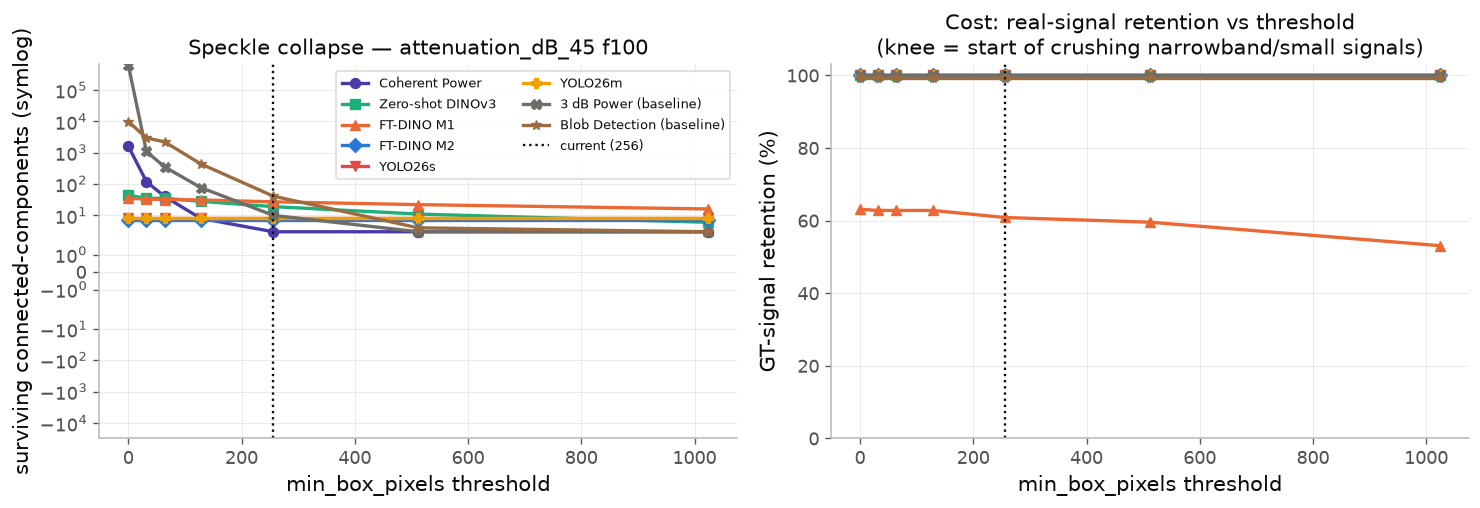

In [20]:
MBOX_SWEEP = [int(x) for x in os.environ.get("DS_MBOX_SWEEP", "0,32,64,128,256,512,1024").split(",")]

def fig_minbox_sensitivity(stem=EX_STEM, fnum=EX_FRAME, dets=DETS, fname="fig_minbox_sensitivity.png"):
    gt = _gt_mask(stem, fnum)
    gt_rows = gt.any(axis=1) if gt is not None else None
    ncomp, reten = {}, {}
    for det in dets:
        m = _frame_mask(det, stem, fnum)
        if m is None:
            continue
        lab, n = ndimage.label(m)                          # label ONCE, then sweep thresholds cheaply
        sizes = np.bincount(lab.ravel()) if n else np.array([0])
        ncomp[det] = [int((sizes[1:] >= thr).sum()) if n else 0 for thr in MBOX_SWEEP]
        if gt_rows is not None and gt_rows.any():
            rr = []
            for thr in MBOX_SWEEP:
                keep = sizes >= thr; keep[0] = False        # drop background + sub-threshold comps
                md_rows = keep[lab].any(axis=1)
                rr.append(float((gt_rows & md_rows).sum()) / float(gt_rows.sum()))
            reten[det] = rr
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))
    for det in ncomp:
        ax[0].plot(MBOX_SWEEP, ncomp[det], marker=MARKER[det], color=COLOR[det], label=LABEL[det], ms=6)
    ax[0].axvline(MIN_BOX_PIXELS, color="#0b0b0b", ls=":", lw=1.4, label=f"current ({MIN_BOX_PIXELS})")
    ax[0].set_yscale("symlog"); ax[0].set_xlabel("min_box_pixels threshold")
    ax[0].set_ylabel("surviving connected-components (symlog)")
    ax[0].set_title(f"Speckle collapse — {stem} f{fnum}")
    for det in reten:
        ax[1].plot(MBOX_SWEEP, [100*v for v in reten[det]], marker=MARKER[det], color=COLOR[det],
                   label=LABEL[det], ms=6)
    ax[1].axvline(MIN_BOX_PIXELS, color="#0b0b0b", ls=":", lw=1.4)
    ax[1].set_xlabel("min_box_pixels threshold"); ax[1].set_ylabel("GT-signal retention (%)")
    ax[1].set_title("Cost: real-signal retention vs threshold\n(knee = start of crushing narrowband/small signals)")
    ax[1].set_ylim(0, 103)
    ax[0].legend(fontsize=8, ncol=2); fig.tight_layout()
    save_fig(fig, fname); display(fig); plt.close(fig)
fig_minbox_sensitivity()